In [1]:
# --- I/O & Core Libraries ---
import os
import math
import numpy as np
import pandas as pd
import anndata as ad

# --- SpatialData / Xenium ---
import spatialdata as sd
from spatialdata_io import xenium
from spatialdata.models import ShapesModel

# --- Geometry / Geospatial ---
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, Point
from shapely.ops import unary_union

# --- Plotting ---
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# --- Single-cell / Spatial Analysis ---
import scanpy as sc
import squidpy as sq
import spatialdata_plot

/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, d

In [2]:
merged_dt = sd.read_zarr('/Users/mzarodniuk/Documents/Scripts/microgravity-gbm/02_st-xenium/data/merged_xenium_sdata.zarr')

version mismatch: detected: RasterFormatV02, requested: FormatV04
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignori

In [3]:
sample_list = [i.split("-")[1] for i in merged_dt.tables.keys()]

In [4]:
gep_assignments_d = pd.read_csv('/Users/mzarodniuk/Documents/Scripts/microgravity-gbm/02_st-xenium/results/xenium_cNMF_k4_gep_assignments.csv', index_col=0)

s = gep_assignments_d["GEP_assignment"]
a = gep_assignments_d[['GEP1_score', 'GEP2_score', 'GEP3_score', 'GEP4_score']]

s = s.astype("string")

lists = s.fillna("").apply(lambda x: x.split(",") if x else [])

onehot = (
    lists.explode()
    .str.strip()
    .pipe(pd.get_dummies)
    .groupby(level=0)
    .max()
)

onehot = onehot.reindex(s.index, fill_value=0)
onehot = onehot.rename(columns=lambda c: f"GEP_{c}").astype(int)

gep_assignments = pd.concat([onehot, a], axis=1)
gep_assignments.index = gep_assignments_d["cell_id"]
gep_assignments.index.name = "cell_id"

In [5]:
for name, adata in merged_dt.tables.items():
    if not name.startswith("table-"):
        continue

    # Align GEP rows to AnnData obs (index must be cell_id)
    # Ensure adata.obs.index is cell_id
    adata.obs.index = adata.obs["cell_id"]             # if not already
    adata.obs.index.name = "cell_id"             # if not already
    
    # Reindex GEP df to match AnnData obs rows
    # Missing cells get NaN
    gep_aligned = gep_assignments.reindex(adata.obs.index)

    # 3. Add GEP columns to obs (same size, same order)
    for gep in range(1, 5):
        adata.obs[f"GEP_{gep}"] = gep_aligned[f"GEP_{gep}"].values
        adata.obs[f"GEP{gep}_score"] = gep_aligned[f"GEP{gep}_score"].values

    adata.obs = adata.obs.reset_index(drop=True)
    
    merged_dt.tables[name] = adata

for name, adata in merged_dt.tables.items():
    if "table-" not in name:
        continue
    mask = adata.obs["GEP_1"].notna()
    merged_dt.tables[name] = adata[mask].copy()

/opt/miniconda3/envs/xenium_env/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table-KSC_U87` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/opt/miniconda3/envs/xenium_env/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table-KSC_UM2` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/opt/miniconda3/envs/xenium_env/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/miniconda3/envs/xenium_env/l

/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `cell_boundaries-KSC_U87` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table-KSC_U87` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Ke

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

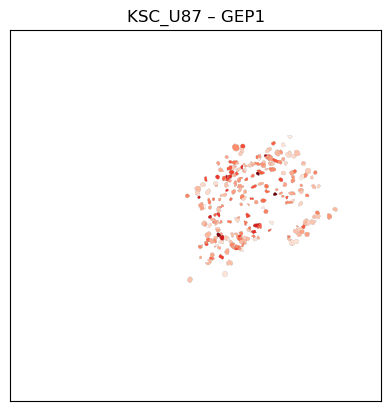

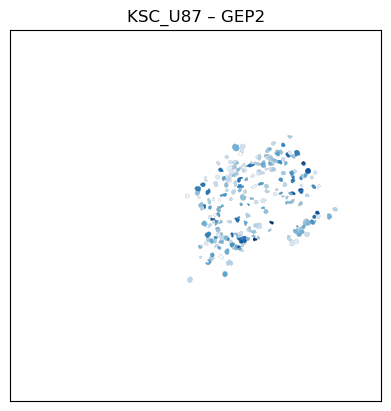

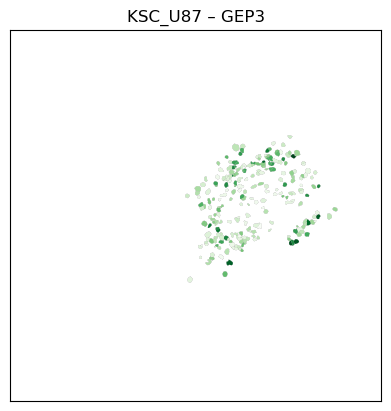

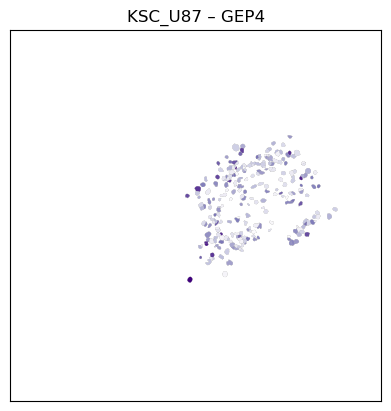

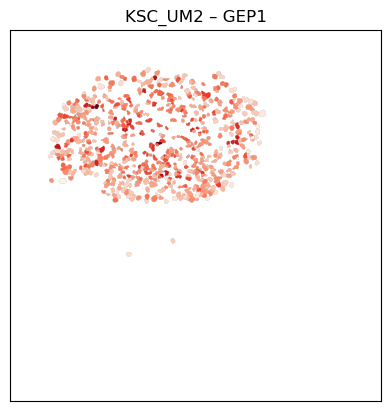

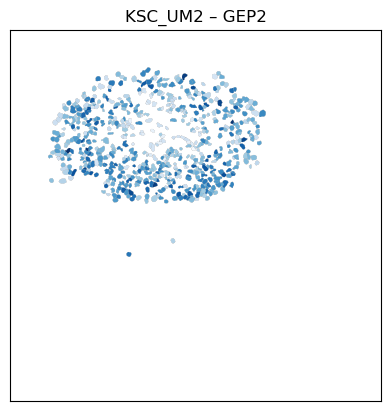

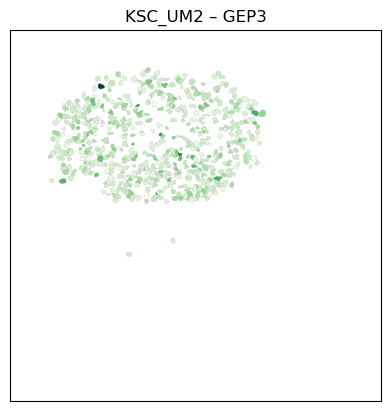

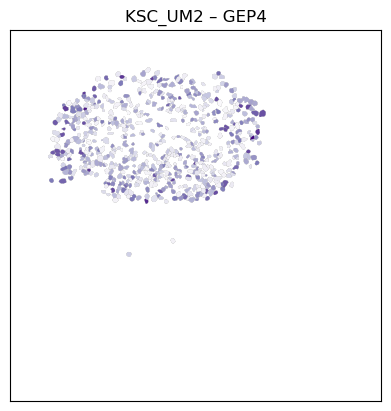

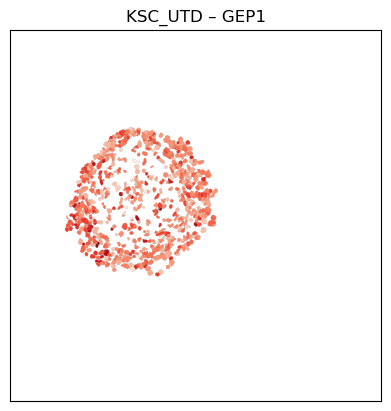

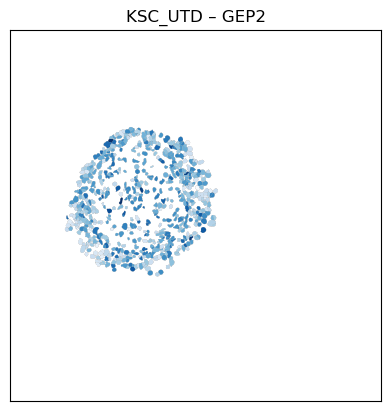

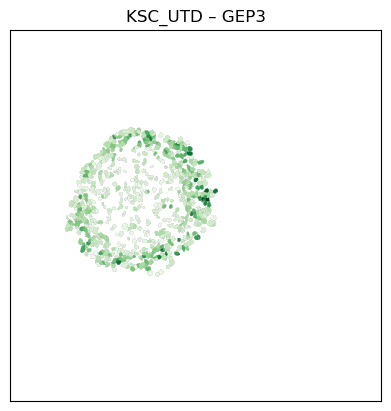

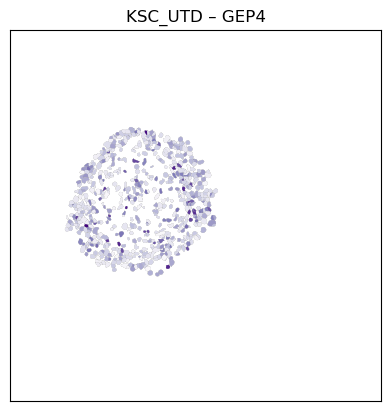

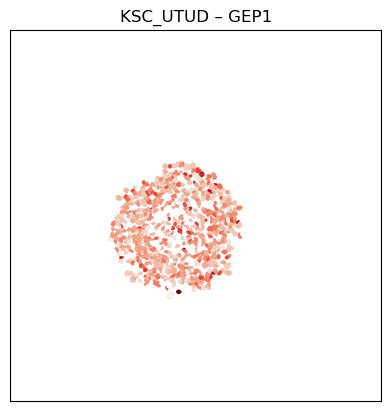

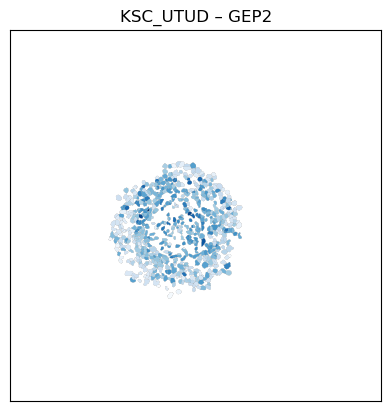

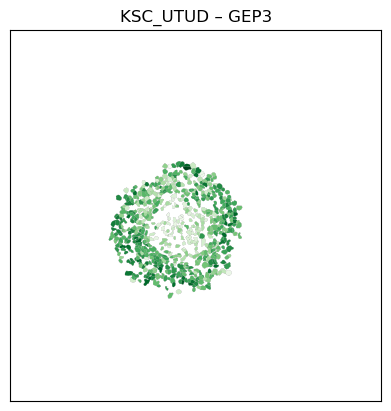

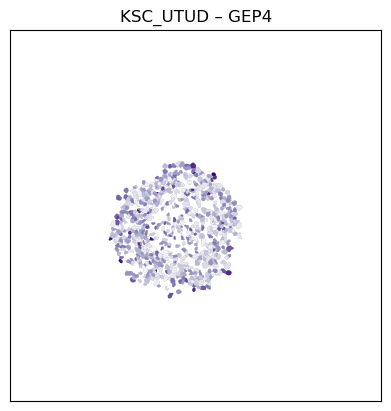

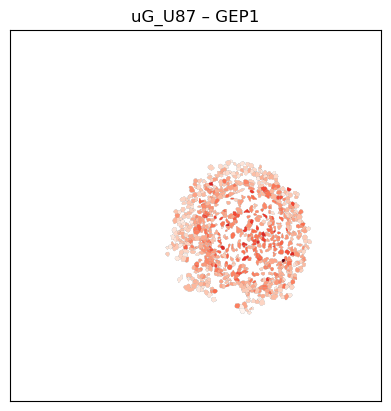

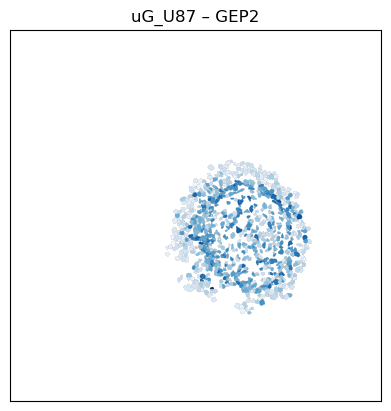

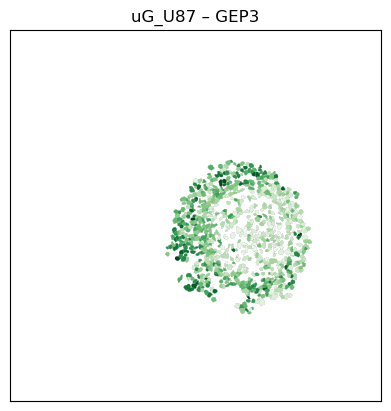

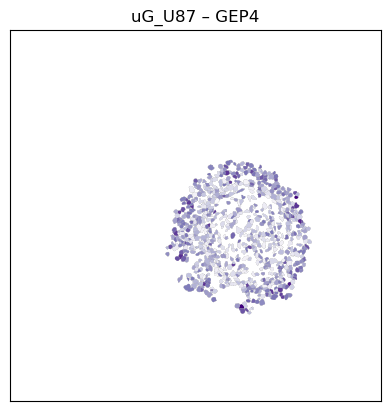

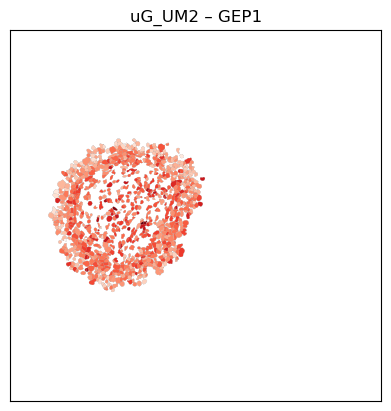

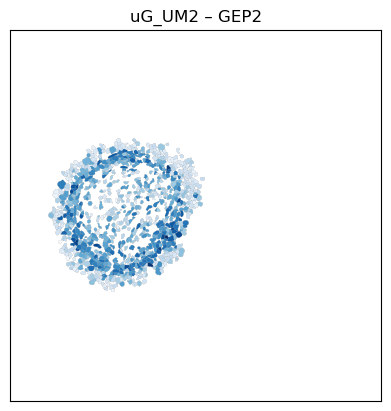

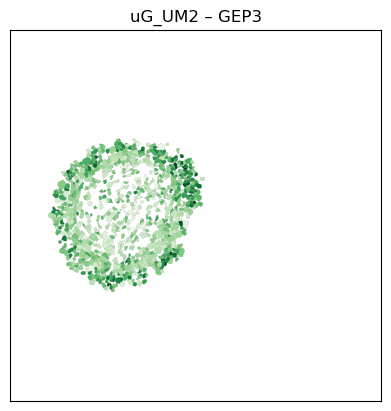

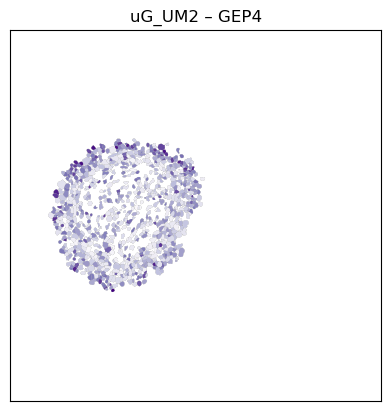

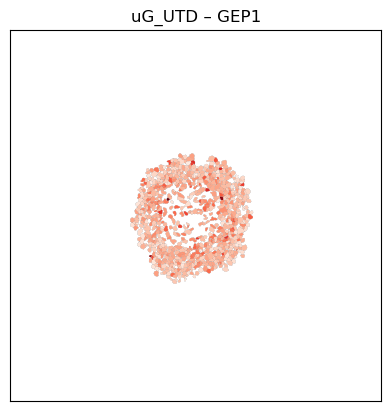

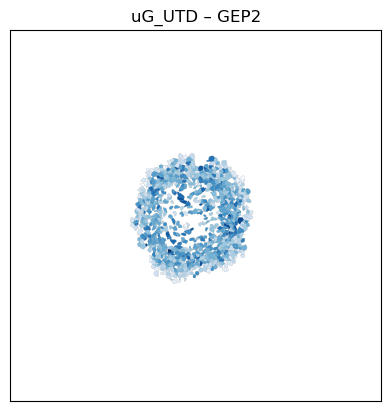

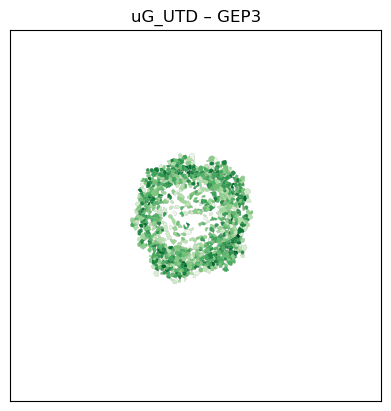

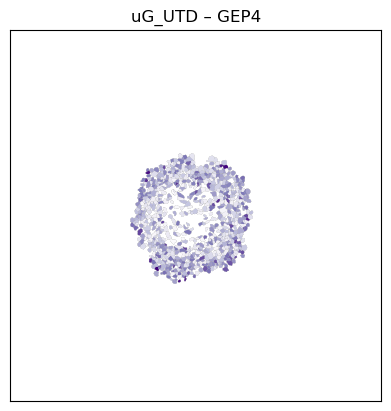

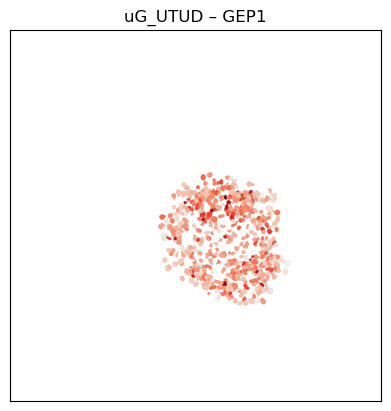

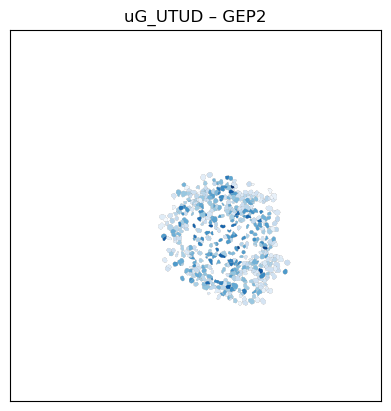

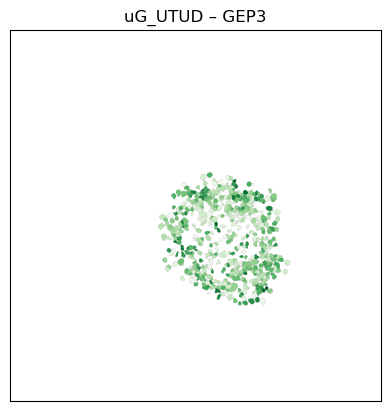

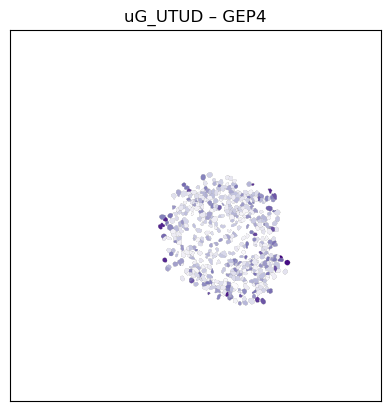

In [6]:
import numpy as np

# --- PASS 1: determine a single global span (max needed across all plots) ---
span_global = 0.0

sample_list = [i.split("-")[1] for i in merged_dt.tables.keys()]
col_pallette = {1: "Reds", 2: "Blues", 3: "Greens", 4: "Purples"}

for sample in sample_list:
    for gep in range(1, 5):
        merged_dt.tables[f"table-{sample}"].obs["region"] = f"cell_boundaries-{sample}"
        merged_dt.set_table_annotates_spatialelement(f"table-{sample}", region=f"cell_boundaries-{sample}")

        plotter = merged_dt.pl.render_shapes(
            f"cell_boundaries-{sample}",
            color=f"GEP{gep}_score",
            outline_color="black",
            outline_width=0.1,
            cmap=col_pallette[gep]
        )
        ax = plotter.pl.show(return_ax=True, colorbar=False)

        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()

        span_here = max(xmax - xmin, ymax - ymin)
        span_global = max(span_global, span_here)

        # close to avoid accumulating figures if you're running many
        ax.get_figure().clf()

# optional: add a little padding so edges aren't tight
span_global *= 1.02


# --- PASS 2: make plots with consistent span but sample-specific centers ---
for sample in sample_list:
    for gep in range(1, 5):
        merged_dt.tables[f"table-{sample}"].obs["region"] = f"cell_boundaries-{sample}"
        merged_dt.set_table_annotates_spatialelement(f"table-{sample}", region=f"cell_boundaries-{sample}")

        plotter = merged_dt.pl.render_shapes(
            f"cell_boundaries-{sample}",
            color=f"GEP{gep}_score",
            outline_color="black",
            outline_width=0.1,
            cmap=col_pallette[gep]
        )
        ax = plotter.pl.show(return_ax=True, colorbar=False)

        # --- set consistent color scaling (your existing logic) ---
        if ax.collections:
            ax.collections[0].set_clim(0, 0.5)
        elif ax.images:
            ax.images[0].set_clim(0, 0.5)

        # --- enforce SAME delta (span) everywhere, but keep each plot centered ---
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        xcenter = (xmax + xmin) / 2
        ycenter = (ymax + ymin) / 2

        ax.set_xlim(xcenter - span_global / 2, xcenter + span_global / 2)
        ax.set_ylim(ycenter - span_global / 2, ycenter + span_global / 2)
        ax.set_aspect("equal", adjustable="box")

        ax.set_title(f"{sample} – GEP{gep}")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel(""); ax.set_ylabel("")

        fig = ax.get_figure()
        fig.set_size_inches(4, 4)

        # NOTE: bbox_inches="tight" can change the *output* crop per figure.
        # If you want identical framing across PDFs, remove bbox_inches="tight".
        fig.savefig(
            f"/Users/mzarodniuk/Documents/Scripts/microgravity-gbm/02_st-xenium/figures/shape_plots/{sample}_GEP{gep}.pdf",
            # bbox_inches="tight"
        )

In [11]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def black_to_cmap(name: str, start: float = 0.25, n: int = 256):
    base = mpl.colormaps[name]
    colors = base(np.linspace(start, 1, n))
    colors[0] = (0, 0, 0, 1)  # minimum = black
    return LinearSegmentedColormap.from_list(f"{name}_black", colors, N=n)

col_palette = {
    1: black_to_cmap("Reds",    start=0.25),
    2: black_to_cmap("Blues",   start=0.25),
    3: black_to_cmap("Greens",  start=0.25),
    4: black_to_cmap("Purples", start=0.25),
}

vmin, vmax = 0.0, 0.5
outdir = "/Users/mzarodniuk/Documents/Scripts/microgravity-gbm/02_st-xenium/figures/shape_plots"

for sample in sample_list:
    for gep in range(1, 5):
        merged_dt.tables[f"table-{sample}"].obs["region"] = f"cell_boundaries-{sample}"
        merged_dt.set_table_annotates_spatialelement(
            f"table-{sample}", region=f"cell_boundaries-{sample}"
        )

        cmap = col_palette[gep].copy()
        cmap.set_bad((0, 0, 0, 0))  # NaNs transparent (optional)

        plotter = merged_dt.pl.render_shapes(
            f"cell_boundaries-{sample}",
            color=f"GEP{gep}_score",
            cmap=cmap,
            outline_color=None,
            outline_width=0.0
        )
        ax = plotter.pl.show(return_ax=True, colorbar=False)

        # white background (default, but set explicitly)
        ax.set_facecolor("white")
        fig = ax.get_figure()
        fig.patch.set_facecolor("white")

        # consistent color scaling
        if ax.collections:
            ax.collections[0].set_clim(vmin, vmax)
        if ax.images:
            ax.images[0].set_clim(vmin, vmax)

        # consistent framing
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        xcenter = (xmax + xmin) / 2
        ycenter = (ymax + ymin) / 2
        ax.set_xlim(xcenter - span_global / 2, xcenter + span_global / 2)
        ax.set_ylim(ycenter - span_global / 2, ycenter + span_global / 2)
        ax.set_aspect("equal", adjustable="box")

        ax.set_title(f"{sample} – GEP{gep}", color="black")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel(""); ax.set_ylabel("")

        fig.set_size_inches(4, 4)

        fig.savefig(
            f"{outdir}/{sample}_GEP{gep}_black.pdf",
            facecolor=fig.get_facecolor(),
            edgecolor="none",
        )
        plt.close(fig)

/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `cell_boundaries-KSC_U87` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table-KSC_U87` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Ke

## Create spheroid masks

Create a spheroid mask and then create concentric shells of fixed thickenss.

In [32]:
# helper functions

# Reduce to a single Polygon (ignore weird pieces)
def largest_polygon(geom):
    # input: shapely geometry

    # if the geometry is already a single polygon, return it
    if isinstance(geom, Polygon):
        return geom

    # get all polygon objects from multipolygon
    polys = [g for g in getattr(geom, "geoms", []) if isinstance(g, Polygon) and not g.is_empty]

    # select polygon with the largest area
    # key lets max know which property to use for comparison
    # lambda is an anonymous function that returns area for each polygon p
    return max(polys, key=lambda p: p.area)

def make_concentric_shells(poly, shell_width, min_core_area=0.0, smooth_step=0.0):
    """
    Take a spheroid polygon and split it into concentric shells of fixed thickness
    (in the same coordinate units as the polygon).

    Parameters
    ----------
    poly : shapely.geometry.Polygon or MultiPolygon
        Outer spheroid outline.
    shell_width : float
        Thickness of each shell (same units as `poly` coordinates).
    min_core_area : float, optional
        Stop when the remaining core area drops below this value. When 0, the last shell is at least shell_width.
    smooth_step : float, optional
        Controls how much moothing is applied to inner shells to remove raggedness. If > 0, shell at level L is smoothed with
        radius (L+1) * smooth_step via buffer(+r).buffer(-r), except for level=0.

    Returns
    -------
    shells : list[tuple[int, Polygon]]
        List of (level, Polygon) from outside (0) toward inside.
    core : Polygon
        Final innermost Polygon (may be empty if eroded away).
    """
    shells = []
    current_outer = largest_polygon(poly)  # in case poly is a MultiPolygon
    # level is incremented inward
    level = 0

    # the loop will break if the spheroid is eroded or core area is less than min_core_area
    while True:
        # Erode inward
        inner = current_outer.buffer(-shell_width)
        if inner.is_empty:
            break

        inner = largest_polygon(inner)  # in case erosion fragmented it

        # The "ring" between outer and inner
        ring = current_outer.difference(inner)
        if isinstance(ring, (Polygon, MultiPolygon)):
            ring = largest_polygon(ring)

        # Optional smoothing: each subsequent shell gets slightly more smoothing
        if level > 0 and smooth_step > 0 and not ring.is_empty:
            r_smooth = smooth_step * (level + 1) * 10
            ring_sm = ring.buffer(r_smooth).buffer(-r_smooth)
            if isinstance(ring_sm, (Polygon, MultiPolygon)) and not ring_sm.is_empty:
                ring = largest_polygon(ring_sm)

        if not ring.is_empty and ring.area > 0:
            shells.append((level, ring))

        current_outer = inner
        level += 1
        
        # optional: stop if core is tiny
        if current_outer.area < min_core_area:
            print("current_outer.area < min_core_area!")
            break

    core = current_outer

    if core is not None and not core.is_empty and core.area > 0:
        shells.append((level, core))

    core = current_outer
    return shells, core


In [33]:
for sample in sample_list:
    # GeoPandas GeoDataFrame where each row represents geometry of the cell
    # Polygon objects list vertex coordinates of the polygon
    cells = merged_dt.shapes[f"cell_boundaries-{sample}"]

    # cells.geometry is a geoseries of cell boundaries
    # .buffer(b) grows or shrinks each polygon by distance b
    dilated = cells.geometry.buffer(10)

    # Union of all cell polygons
    # combines all genometries into on multipolygon object
    u = unary_union(dilated)

    # select the largest polygon
    base_poly = largest_polygon(u)

    # dilate and erode
    smooth_poly = base_poly.buffer(20).buffer(-20)

    # Make sure dilation didn’t turn it into MultiPolygon again
    smooth_poly = largest_polygon(smooth_poly)

    # Wrap into GeoDataFrame
    shell_gdf = gpd.GeoDataFrame(geometry=[smooth_poly])

    # Preserve spatialdata attrs if present
    # these attributes contain info about coord system and transformations
    if "transform" in cells.attrs:
        shell_gdf.attrs["transform"] = cells.attrs["transform"]

    # converts the geodataframe into a spatialdata-compalible object (shapesmodel)
    shell_shapes = ShapesModel.parse(shell_gdf)
    merged_dt.shapes[f"outer_shell-{sample}"] = shell_shapes

    # create concentric shells
    spheroid_poly = shell_shapes.geometry.iloc[0]
    shells, core = make_concentric_shells(spheroid_poly, shell_width=60, smooth_step=0, min_core_area=50000)

    # need to create a shapesmodel to add to spatialdata
    # first, need to create a geodataframe
    # unpack levels & geometries
    levels = [lvl for lvl, geom in shells]
    geoms  = [geom for lvl, geom in shells]

    shells_gdf = gpd.GeoDataFrame(
        {"level": levels},
        geometry=geoms,
    )

    # give shells the same transform as your spheroid or cell boundaries
    base_shapes = merged_dt.shapes[f"outer_shell-{sample}"]
    if "transform" in base_shapes.attrs:
        shells_gdf.attrs["transform"] = base_shapes.attrs["transform"]

    # parse to ShapesModel and store in SpatialData
    merged_dt.shapes[f"spheroid_radial_shells-{sample}"] = ShapesModel.parse(shells_gdf)

current_outer.area < min_core_area!
current_outer.area < min_core_area!
current_outer.area < min_core_area!
current_outer.area < min_core_area!
current_outer.area < min_core_area!
current_outer.area < min_core_area!
current_outer.area < min_core_area!
current_outer.area < min_core_area!


In [ ]:
"""for sample in sample_list:
    plotter = (
        merged_dt.pl
        .render_shapes(f"cell_boundaries-{sample}",
                    color=None, fill_alpha=0,
                    outline_color="black", outline_width=0.3)
        .pl.render_shapes(f"spheroid_radial_shells-{sample}",
                        color="level",   # color shells by level
                        fill_alpha=0.3,
                        cmap="magma")
    )

    ax = plotter.pl.show(return_ax=True)

    # --- rescale cmap to [0, 0.5] without changing data ---
    # Try to grab the first mappable artist (scatter/collection/etc.)
    if ax.collections:
        mappable = ax.collections[0]
    elif ax.images:
        mappable = ax.images[0]
    else:
        mappable = None

    if mappable is not None:
        # Option 1: just set clim (simplest)
        mappable.set_clim(0, 0.5)

        # (optional) if you prefer explicit norm:
        # mappable.set_norm(mcolors.Normalize(vmin=0, vmax=0.5))

    # --- keep your square axis logic ---
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    span = max(xmax - xmin, ymax - ymin)
    xcenter = (xmax + xmin) / 2
    ycenter = (ymax + ymin) / 2

    ax.set_xlim(xcenter - span / 2, xcenter + span / 2)
    ax.set_ylim(ycenter - span / 2, ycenter + span / 2)

    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"{sample} – GEP{gep}")

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.set_xlabel("")
    ax.set_ylabel("")

    fig = ax.get_figure()
    fig.set_size_inches(4, 4)
    fig.savefig(f"figures/shell_plots/{sample}.pdf", bbox_inches="tight")"""

### Assign cells to shells

In [ ]:
"""def assign_cells_to_shells(merged_dt, sample, shells_key=None, table_key=None,
                           colname="shell_level", predicate="within"):
    """
    For a given sample, assign each cell to a spheroid shell and store the
    shell level in merged_dt.tables[table_key].obs[colname].

    Parameters
    ----------
    merged_dt : SpatialData
    sample : str
        Sample name, e.g. "uG_U87".
    shells_key : str or None
        Name in merged_dt.shapes for shells. If None, uses f"spheroid_radial_shells-{sample}".
    table_key : str or None
        Name in merged_dt.tables for cell table. If None, uses f"table-{sample}".
    colname : str
        Name of column to create in .obs (e.g. "shell_level").
    predicate : str
        Spatial relation: "within" (points strictly inside shells) or "intersects".
    """
    if shells_key is None:
        shells_key = f"spheroid_radial_shells-{sample}"
    if table_key is None:
        table_key = f"table-{sample}"

    # 1) Get AnnData table and centroids
    tbl = merged_dt.tables[table_key]
    coords = tbl.obsm["spatial"]  # shape (n_cells, 2): x, y
    cell_ids = tbl.obs.index

    # 2) Build GeoDataFrame of cell centroids
    cells_gdf = gpd.GeoDataFrame(
        tbl.obs.copy(),
        geometry=gpd.points_from_xy(coords[:, 0], coords[:, 1]),
        index=cell_ids,
    )

    # 3) Get shells as a GeoDataFrame-like from SpatialData
    shells = merged_dt.shapes[shells_key]  # should have a "level" column and geometry

    # Make sure we only keep what we need
    shells = shells[["level", "geometry"]]

    # 4) Spatial join: assign each cell to the shell polygon that contains it
    #    'how="left"' means keep all cells, unmatched cells get NaN level
    joined = gpd.sjoin(
        cells_gdf,
        shells,
        how="left",
        predicate=predicate,  # "within" is typical; "intersects" if needed
    )

    # After sjoin, the shell level is in a column like "level_right" (depending on geopandas version).
    # Let's detect/standardize the name.
    level_col = "level_right" if "level_right" in joined.columns else "level"
    shell_levels = joined[level_col]

    # 5) Write back into AnnData.obs (aligned by index)
    # Make sure index alignment is correct: joined index == tbl.obs.index
    shell_levels = shell_levels.reindex(tbl.obs.index)
    tbl.obs[colname] = shell_levels.values

    return tbl  # optional; now merged_dt.tables[table_key].obs has the new column
"""

In [ ]:
"""for sample in sample_list:

    assign_cells_to_shells(
        merged_dt,
        sample=sample,
        shells_key=f"spheroid_radial_shells-{sample}",
        table_key=f"table-{sample}",
        colname="shell_level",
        predicate="within",   # or "intersects" if cells lie exactly on borders
    )"""

In [ ]:
"""cell_counts = []

for sample in sample_list:
    tbl = merged_dt.tables[f"table-{sample}"]
    sample_cell_counts = pd.DataFrame({"count": tbl.obs["shell_level"].value_counts(dropna=False), "sample": sample})
    sample_cell_counts["shell_level"] = sample_cell_counts.index
    sample_cell_counts = sample_cell_counts.reset_index(drop=True)
    cell_counts.append(sample_cell_counts)

pd.concat(cell_counts)"""

,count,sample,shell_level
0,144,KSC_U87,0.0
1,82,KSC_U87,1.0
2,21,KSC_U87,NaN
0,250,KSC_UM2,1.0
1,210,KSC_UM2,0.0
2,157,KSC_UM2,2.0
3,37,KSC_UM2,3.0
4,2,KSC_UM2,NaN
0,337,KSC_UTD,0.0
1,217,KSC_UTD,1.0


WARNING  Found 2 NaN values in color data. These observations will be colored with the 'na_color'.                 


/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `cell_boundaries-KSC_UM2` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table-KSC_UM2` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


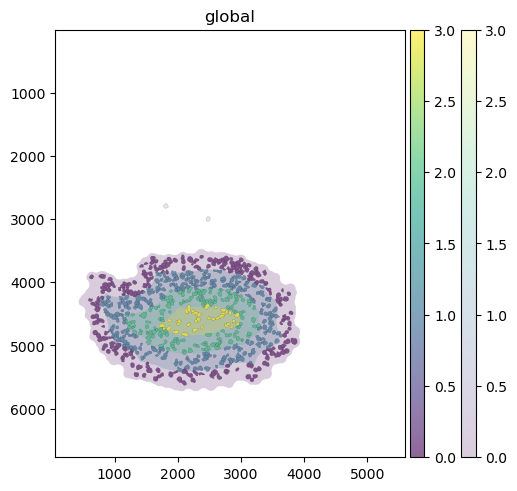

In [ ]:
"""sample = "KSC_UM2"

(
    merged_dt.pl
    # 1) Plot shells, colored by level
    .render_shapes(
        element=f"spheroid_radial_shells-{sample}",
        color="level",
        cmap="viridis",
        fill_alpha=0.2,
    )
    # 2) Overlay cell boundaries, colored by shell_level from the table
    .pl.render_shapes(
        element=f"cell_boundaries-{sample}",
        color="shell_level",                  # column in table.obs
        table_name=f"table-{sample}",         # tell it where to find that column
        cmap="viridis",
        fill_alpha=0.6,
        outline_color="black",
        outline_width=0.1,
    )
    .pl.show()
)"""

### Approach 2: shells are defined based on per-cell distance from the roid core

In [34]:
for sample in sample_list:
    # load the spheroid outer polygon (usually 1 Polygon)
    shells = merged_dt.shapes[f"outer_shell-{sample}"]
    outer_poly = shells.geometry.iloc[0]
    outer_boundary = outer_poly.boundary

    # load AnnData table
    tbl = merged_dt.tables[f"table-{sample}"]
    coords = tbl.obsm["spatial"]   # Nx2 array of XY centroids

    dist_list = []
    inside_mask = []

    for x, y in coords:
        pt = Point(x, y)

        if outer_poly.covers(pt):    # True if inside OR exactly on boundary
            inside_mask.append(True)
            dist_list.append(outer_boundary.distance(pt))
        else:
            inside_mask.append(False)
            dist_list.append(np.nan)  # outside cells get NaN

    dists = np.array(dist_list)
    tbl.obs["dist_to_boundary"] = dists

    # normalize ONLY interior distances
    if np.any(~np.isnan(dists)):
        max_dist = np.nanmax(dists)
        tbl.obs["radial_norm_boundary"] = dists / max_dist
    else:
        tbl.obs["radial_norm_boundary"] = np.nan

In [37]:
merged_dt.shapes

{'cell_boundaries-KSC_U87':                                                      geometry
aagandaf-1  POLYGON ((541.875 292.613, 541.663 292.825, 54...
aagfojgm-1  POLYGON ((567.163 303.238, 564.4 306, 563.125 ...
aajpfdbi-1  POLYGON ((560.362 296.863, 559.725 297.075, 55...
abdlelij-1  POLYGON ((557.388 277.1, 555.475 277.95, 554.4...
abgjbdie-1  POLYGON ((614.55 247.138, 611.15 248.838, 609....
...                                                       ...
ohaeekpo-1  POLYGON ((583.95 445.825, 583.737 446.038, 583...
ohaghbck-1  POLYGON ((598.188 453.688, 597.55 453.9, 592.4...
ohchfmem-1  POLYGON ((589.9 412.888, 588.838 413.312, 587....
ohdienbe-1  POLYGON ((584.588 418.2, 583.737 420.75, 584.1...
ohilmmpj-1  POLYGON ((581.612 417.562, 579.487 418.413, 57...

[451 rows x 1 columns], 'cell_boundaries-KSC_UM2':                                                      geometry
aabemicf-1  POLYGON ((377.825 569.713, 375.7 570.562, 374....
aaebpjkd-1  POLYGON ((583.737 640.475, 582.888 640.9

WARNING  Found 21 NaN values in color data. These observations will be colored with the 'na_color'.                


/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `cell_boundaries-KSC_U87` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table-KSC_U87` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


WARNING  Found 2 NaN values in color data. These observations will be colored with the 'na_color'.                 


/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `cell_boundaries-KSC_UM2` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table-KSC_UM2` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `cell_boundaries-KSC_UTD` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table-KSC_UTD` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata

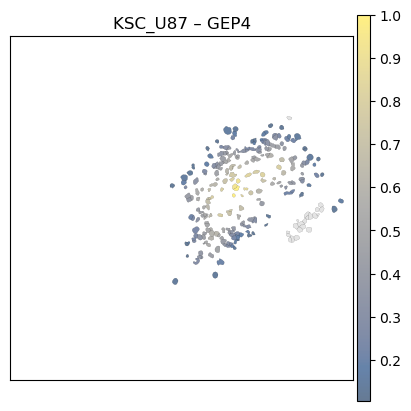

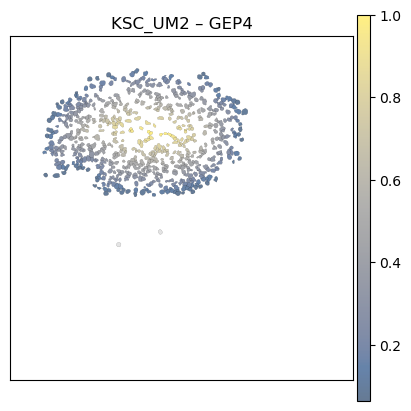

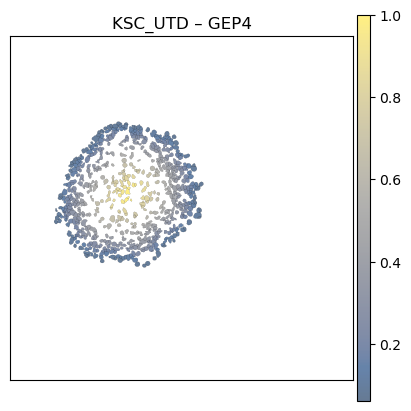

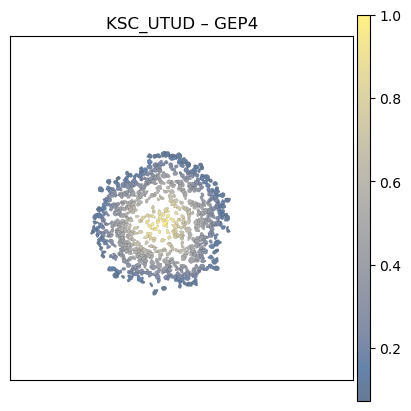

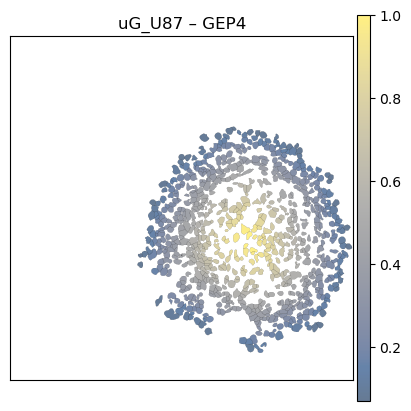

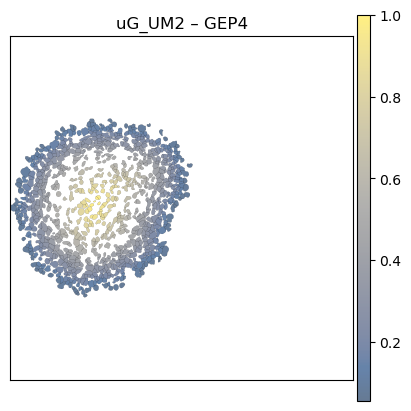

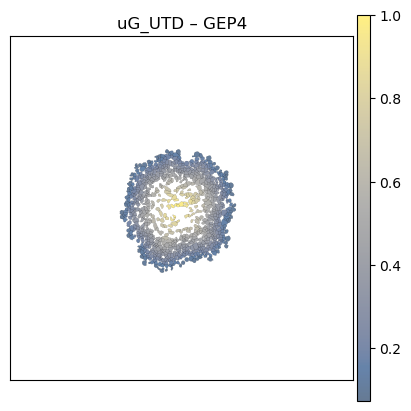

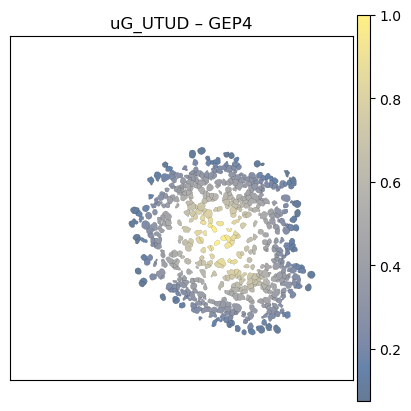

In [43]:
for sample in sample_list:
    plotter = merged_dt.pl.render_shapes(element=f"cell_boundaries-{sample}",
        color="radial_norm_boundary",                  # column in table.obs
        table_name=f"table-{sample}",         # tell it where to find that column
        cmap="cividis",
        fill_alpha=0.6,
        outline_color="black",
        outline_width=0.1,)

    ax = plotter.pl.show(return_ax=True)

    # --- rescale cmap to [0, 0.5] without changing data ---
    # Try to grab the first mappable artist (scatter/collection/etc.)
    if ax.collections:
        mappable = ax.collections[0]
    elif ax.images:
        mappable = ax.images[0]
    else:
        mappable = None

    if mappable is not None:
        # Option 1: just set clim (simplest)
        mappable.set_clim(0, 0.5)

        # (optional) if you prefer explicit norm:
        # mappable.set_norm(mcolors.Normalize(vmin=0, vmax=0.5))

    # --- keep your square axis logic ---
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    span = max(xmax - xmin, ymax - ymin)
    xcenter = (xmax + xmin) / 2
    ycenter = (ymax + ymin) / 2

    ax.set_xlim(xcenter - span / 2, xcenter + span / 2)
    ax.set_ylim(ycenter - span / 2, ycenter + span / 2)

    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"{sample} – GEP{gep}")

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.set_xlabel("")
    ax.set_ylabel("")

    fig = ax.get_figure()
    fig.set_size_inches(4, 4)
    fig.savefig(f"figures/dist_plots/{sample}.pdf", bbox_inches="tight")

In [44]:
# split the cells into three equally sized bins

for sample in sample_list:
    tbl = merged_dt.tables[f"table-{sample}"]

    # make sure it's there
    r = tbl.obs["radial_norm_boundary"]

    # 3 equal-width bins: [0, 1/3), [1/3, 2/3), [2/3, 1]
    tbl.obs["radial_layer"] = pd.cut(
        r,
        bins=[0.0, 1/3, 2/3, 1.0],
        labels=["periphery", "middle", "core"],
        include_lowest=True,
    )

In [45]:
from matplotlib.colors import to_hex


cmap = plt.get_cmap("cividis")
hex_colors = [to_hex(cmap(x)) for x in np.linspace(0, 1, 3)]
print(hex_colors)

['#00224e', '#7d7c78', '#fee838']


/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `cell_boundaries-KSC_U87` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table-KSC_U87` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata_plot/pl/basic.py:962: UserWarning: Converting copy of 'radial_layer_plot' column to categorical dtype for categorical plotting. Consider converting before plotting.
  _render_shapes(
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_actio

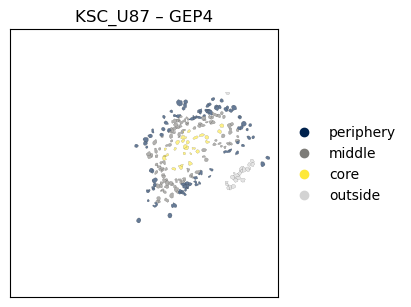

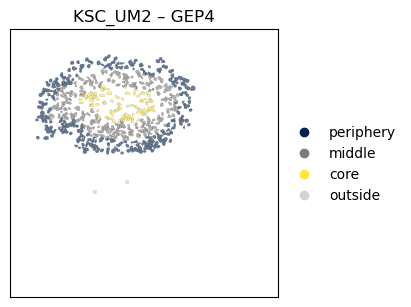

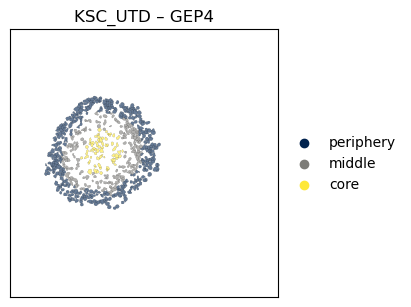

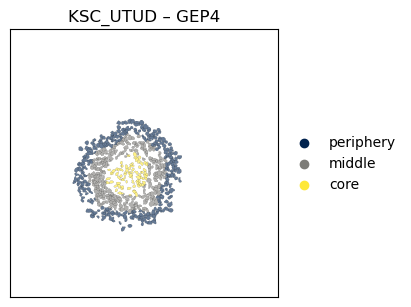

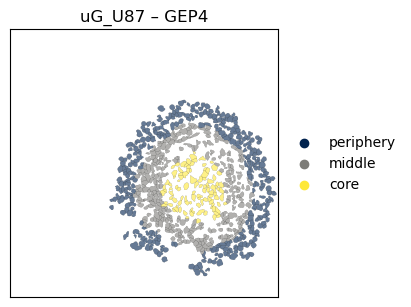

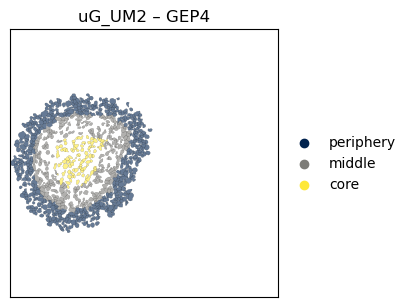

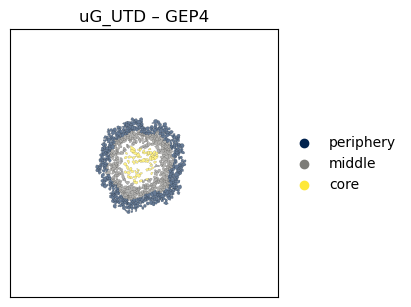

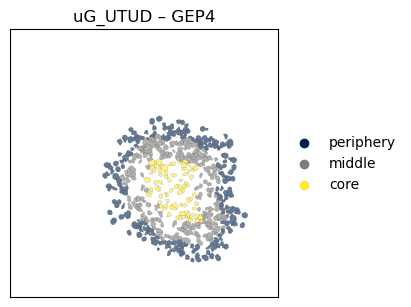

In [47]:
for sample in sample_list:
    tbl = merged_dt.tables[f"table-{sample}"]

    # Make a plot-safe layer column where NaNs are labeled "outside"
    layer = tbl.obs["radial_layer"].astype("object")
    layer = layer.fillna("outside")
    tbl.obs["radial_layer_plot"] = layer

    plotter = (
        merged_dt.pl
        .render_shapes(
            element=f"cell_boundaries-{sample}",
            color="radial_layer_plot",         # use the plot-safe column
            table_name=f"table-{sample}",
            fill_alpha=0.6,
            outline_color="black",
            outline_width=0.1,
            # optional: custom palette if you want
            groups = ["periphery", "middle", "core", "outside"],
            palette=hex_colors + ['lightgray'],
        )
    )

    ax = plotter.pl.show(return_ax=True)

    # --- rescale cmap to [0, 0.5] without changing data ---
    # Try to grab the first mappable artist (scatter/collection/etc.)
    if ax.collections:
        mappable = ax.collections[0]
    elif ax.images:
        mappable = ax.images[0]
    else:
        mappable = None

    if mappable is not None:
        # Option 1: just set clim (simplest)
        mappable.set_clim(0, 0.5)

        # (optional) if you prefer explicit norm:
        # mappable.set_norm(mcolors.Normalize(vmin=0, vmax=0.5))

    # --- keep your square axis logic ---
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    span = max(xmax - xmin, ymax - ymin)
    xcenter = (xmax + xmin) / 2
    ycenter = (ymax + ymin) / 2

    ax.set_xlim(xcenter - span / 2, xcenter + span / 2)
    ax.set_ylim(ycenter - span / 2, ycenter + span / 2)
    
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"{sample} – GEP{gep}")

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.set_xlabel("")
    ax.set_ylabel("")

    fig = ax.get_figure()
    fig.set_size_inches(4, 4)
    fig.savefig(f"figures/dist_bin_plots/{sample}.pdf", bbox_inches="tight")

## Compute area for each of the radial regions

In [63]:
area_results = list()

for sample in sample_list:
    radial_layers = merged_dt.tables[f"table-{sample}"].obs["radial_layer"]

    for layer in ["core", "middle", "periphery"]:

        cell_ids = merged_dt.tables[f"table-{sample}"].obs.cell_id[radial_layers==layer]

        shapes = merged_dt.shapes[f"cell_boundaries-{sample}"].loc[cell_ids].geometry

        exact_union = shapes.unary_union

        bounded_union = (
            shapes
            .buffer(20)
            .unary_union
            .buffer(-20)
        )

        area_results.append(pd.DataFrame({"sample": [sample],
                    "exact_area": [bounded_union.area],
                    "layer": [layer]}))

area_df = pd.concat(area_results)
area_df.to_csv("results/radial_layer_areas.csv", index=False)

/var/folders/20/3tl14sv9545_3kl_wmkgxkc40000gn/T/ipykernel_87040/3234060839.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  exact_union = shapes.unary_union
/var/folders/20/3tl14sv9545_3kl_wmkgxkc40000gn/T/ipykernel_87040/3234060839.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  .unary_union
/var/folders/20/3tl14sv9545_3kl_wmkgxkc40000gn/T/ipykernel_87040/3234060839.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  exact_union = shapes.unary_union
/var/folders/20/3tl14sv9545_3kl_wmkgxkc40000gn/T/ipykernel_87040/3234060839.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  .unary_union
/var/folders/20/3tl14sv9545_3kl_wmkgxkc40000gn/T/ipykernel_87040/3234060839.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all

/var/folders/20/3tl14sv9545_3kl_wmkgxkc40000gn/T/ipykernel_87040/2112739855.py:35: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/20/3tl14sv9545_3kl_wmkgxkc40000gn/T/ipykernel_87040/2112739855.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


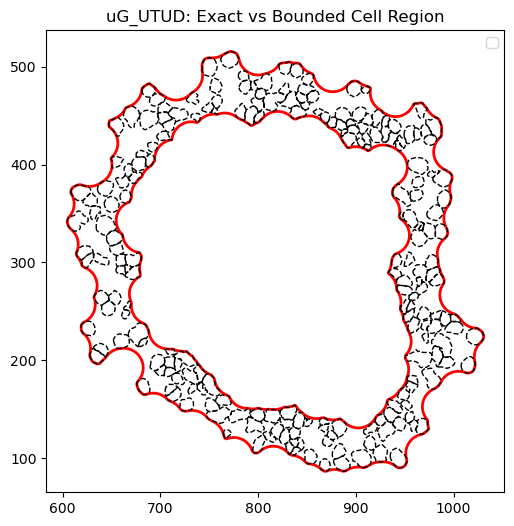

In [64]:
gdf_exact = gpd.GeoDataFrame(
    {"type": ["exact"]},
    geometry=[exact_union],
    crs=merged_dt.shapes[f"cell_boundaries-{sample}"].crs
)

gdf_bounded = gpd.GeoDataFrame(
    {"type": ["bounded"]},
    geometry=[bounded_union],
    crs=merged_dt.shapes[f"cell_boundaries-{sample}"].crs
)

fig, ax = plt.subplots(figsize=(6, 6))

# bounded region (filled)
gdf_bounded.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2,
    label="Bounded (buffer±20)"
)

# exact cell union (outline + holes)
gdf_exact.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1,
    linestyle="--",
    label="Exact cell union"
)

ax.set_aspect("equal")
ax.legend()
ax.set_title(f"{sample}: Exact vs Bounded Cell Region")

plt.show()

/var/folders/20/3tl14sv9545_3kl_wmkgxkc40000gn/T/ipykernel_87040/3940428421.py:25: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/20/3tl14sv9545_3kl_wmkgxkc40000gn/T/ipykernel_87040/3940428421.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


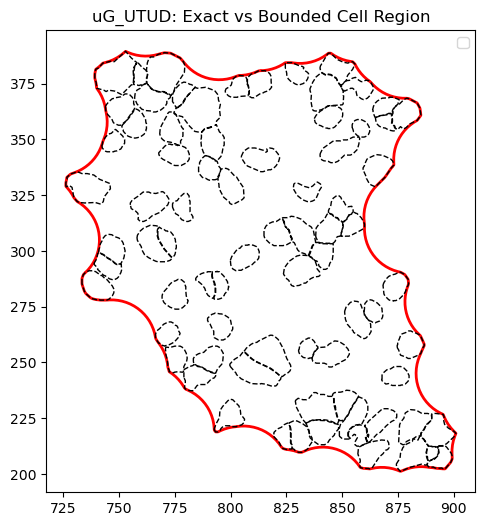

## Moran's I spatial autocorrelation

In [14]:
adata_dict = dict()

for table_name, adata in merged_dt.tables.items():
    
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    adata.layers["lognorm"] = adata.X.copy()

    adata_dict[table_name] = adata
    sq.gr.spatial_neighbors(adata_dict[table_name], coord_type="generic", delaunay=True)
    sq.gr.spatial_autocorr(
        adata_dict[table_name],
        mode="moran",
        n_jobs=-1,
    )

/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 1285 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 896 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 832 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 1123 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()
/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 1013 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()
/opt/miniconda3/e

In [15]:
table_name=list(merged_dt.tables.keys())[6]

adata_dict[table_name].uns["moranI"].sort_values("I", ascending=False)

,I,pval_norm,var_norm,pval_norm_fdr_bh
EEF1G,0.317862,0.0,0.00041,NaN
ANXA2,0.266214,0.0,0.00041,NaN
TFPI2,0.234763,0.0,0.00041,NaN
HSPA6,0.233190,0.0,0.00041,NaN
IL23A,0.213797,0.0,0.00041,NaN
...,...,...,...,...
ZBED9,NaN,NaN,0.00041,NaN
ZBTB16,NaN,NaN,0.00041,NaN
ZFP57,NaN,NaN,0.00041,NaN
ZNF177,NaN,NaN,0.00041,NaN


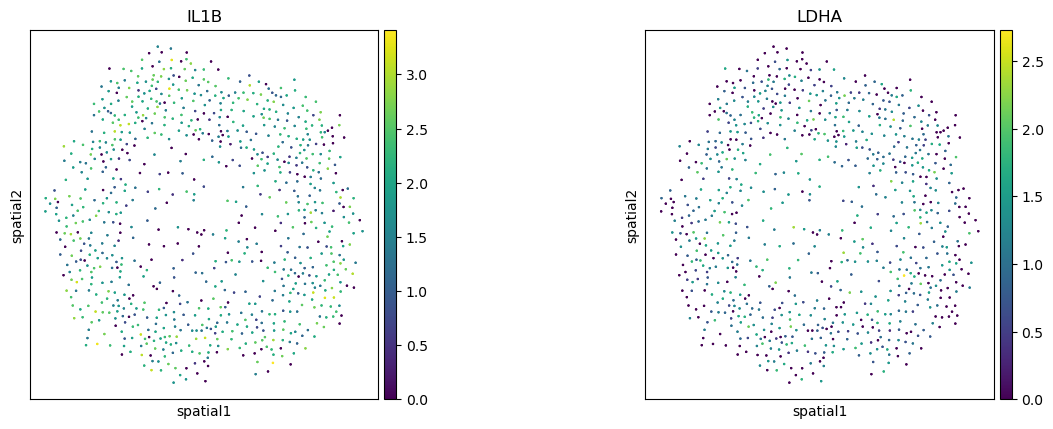

In [386]:
# We can also use squidpy's plotting to plot out the genes
sq.pl.spatial_scatter(
    adata_dict[table_name],
    library_id="spatial",
    color=["IL1B", "LDHA"],
    shape=None,
    size=2,
    img=False
)

## Moran's I spatial autocorrelation on GEPs

In [16]:
gep_adata_dict = dict()

for name, adata in adata_dict.items():

    gep_cols = [c for c in adata.obs.columns if c.startswith("GEP") and c.endswith("_score")]

    X = adata.obs[gep_cols].to_numpy()  # shape: n_cells × n_GEPs

    adata_gep = ad.AnnData(
        X=X,
        obs=adata.obs.copy(),   # keep same cells & metadata
    )

    adata_gep.var_names = gep_cols  # so each "gene" is actually a GEP

    adata_gep.obsp["spatial_connectivities"] = adata.obsp["spatial_connectivities"].copy()
    adata_gep.obsp["spatial_distances"] = adata.obsp["spatial_distances"].copy()

    sq.gr.spatial_autocorr(
        adata_gep,
        mode="moran",   # Moran's I
        genes=gep_cols  # treat each GEP as a "gene"
    )

    gep_adata_dict[name] = adata_gep

In [17]:
moran_df = []

for name, adata in gep_adata_dict.items():
    moran_df_sub = gep_adata_dict[name].uns["moranI"]
    moran_df_sub["name"] = name
    moran_df.append(moran_df_sub)

moran_df = pd.concat(moran_df)

In [18]:
moran_df.to_csv("/Users/mzarodniuk/Documents/Scripts/microgravity-gbm/02_st-xenium/results/GEP_moranI.csv")

In [19]:
ad.concat(adata_dict).obs.to_csv("/Users/mzarodniuk/Documents/Scripts/microgravity-gbm/02_st-xenium/results/spatial_stats.csv")

/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [20]:
ad.concat(adata_dict).layers["counts"].toarray()

/opt/miniconda3/envs/xenium_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 2.],
       ...,
       [0., 0., 0., ..., 1., 0., 2.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)